In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r'C:\Users\Neha\Downloads\AI\10th- Ensemble Learning\Machine Learning CAPSTONE PROJECT\DIBETIC PREDICTION\diabetics_prediction.csv')

In [4]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
data.isna().any()

gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool

In [6]:
data.corr(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


In [7]:
data.shape

(100000, 9)

In [8]:
for column in data.columns:
    unique_values = data[column].unique()
    print('Column "{}" has unique values: {}'.format(column,unique_values))

Column "gender" has unique values: ['Female' 'Male' 'Other']
Column "age" has unique values: [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
Column "hypertension" has unique values: [0 1]
Column "heart_disease" has unique values: [1 0]
Column "smoking_history" has unique values: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
Column "bmi" has unique values: [25.19 27.32 23.45 ... 59.42 44.39 60.52]
Column "HbA1c_level" h

In [9]:
data['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [11]:
data['smoking_history'].value_counts()/len(data)

smoking_history
No Info        0.35816
never          0.35095
former         0.09352
current        0.09286
not current    0.06447
ever           0.04004
Name: count, dtype: float64

In [12]:
data['smoking_history'] = data['smoking_history'].replace('No Info',pd.NA)

mode_value = data['smoking_history'].mode()[0]
data['smoking_history'] = data['smoking_history'].fillna(mode_value)
print(data['smoking_history'].value_counts())

smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [14]:
data.gender.value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [15]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [16]:
data['bmi'] = [float(str(i).replace(",",""))for i in data['bmi']]

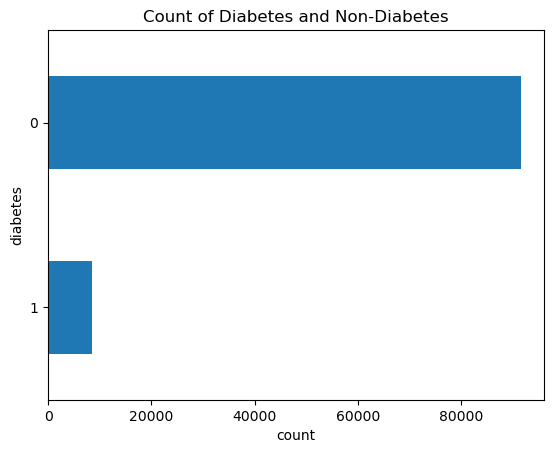

In [17]:
data['diabetes'].value_counts().plot(kind='barh')
plt.xlabel('count')
plt.ylabel('diabetes')
plt.title('Count of Diabetes and Non-Diabetes')
plt.gca().invert_yaxis()
plt.show()

In [18]:
data['diabetes'].value_counts()/len(data)

diabetes
0    0.915
1    0.085
Name: count, dtype: float64

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [20]:
le = LabelEncoder()
le

LabelEncoder()

In [21]:
Label_encod_columns = ['gender','smoking_history']
data[Label_encod_columns] = data[Label_encod_columns].apply(le.fit_transform)

In [22]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,3,25.19,6.6,140,0
1,0,54.0,0,0,3,27.32,6.6,80,0
2,1,28.0,0,0,3,27.32,5.7,158,0
3,0,36.0,0,0,0,23.45,5.0,155,0
4,1,76.0,1,1,0,20.14,4.8,155,0


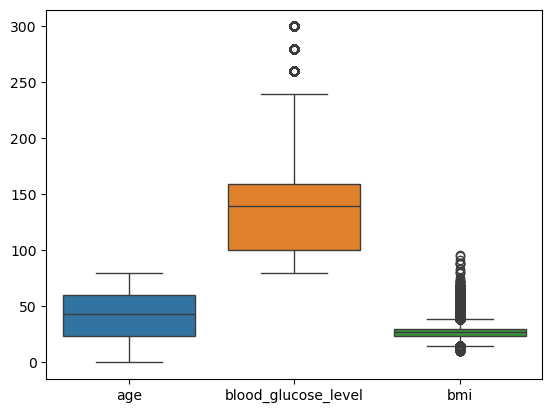

In [27]:
sns.boxplot(data=data[['age','blood_glucose_level','bmi']])
plt.show()

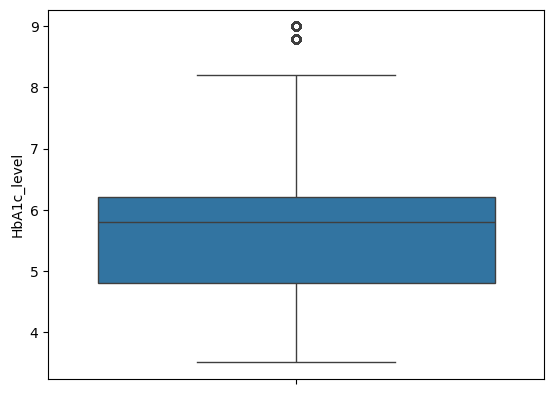

In [28]:
sns.boxplot(data=data['HbA1c_level'])
plt.show()

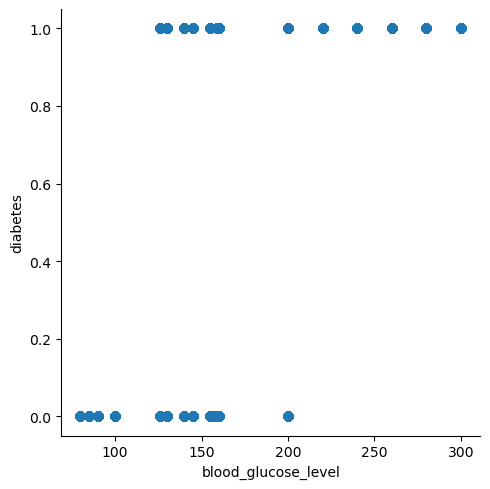

In [29]:
sns.lmplot(data=data,x='blood_glucose_level',y='diabetes',fit_reg=False)
plt.show()

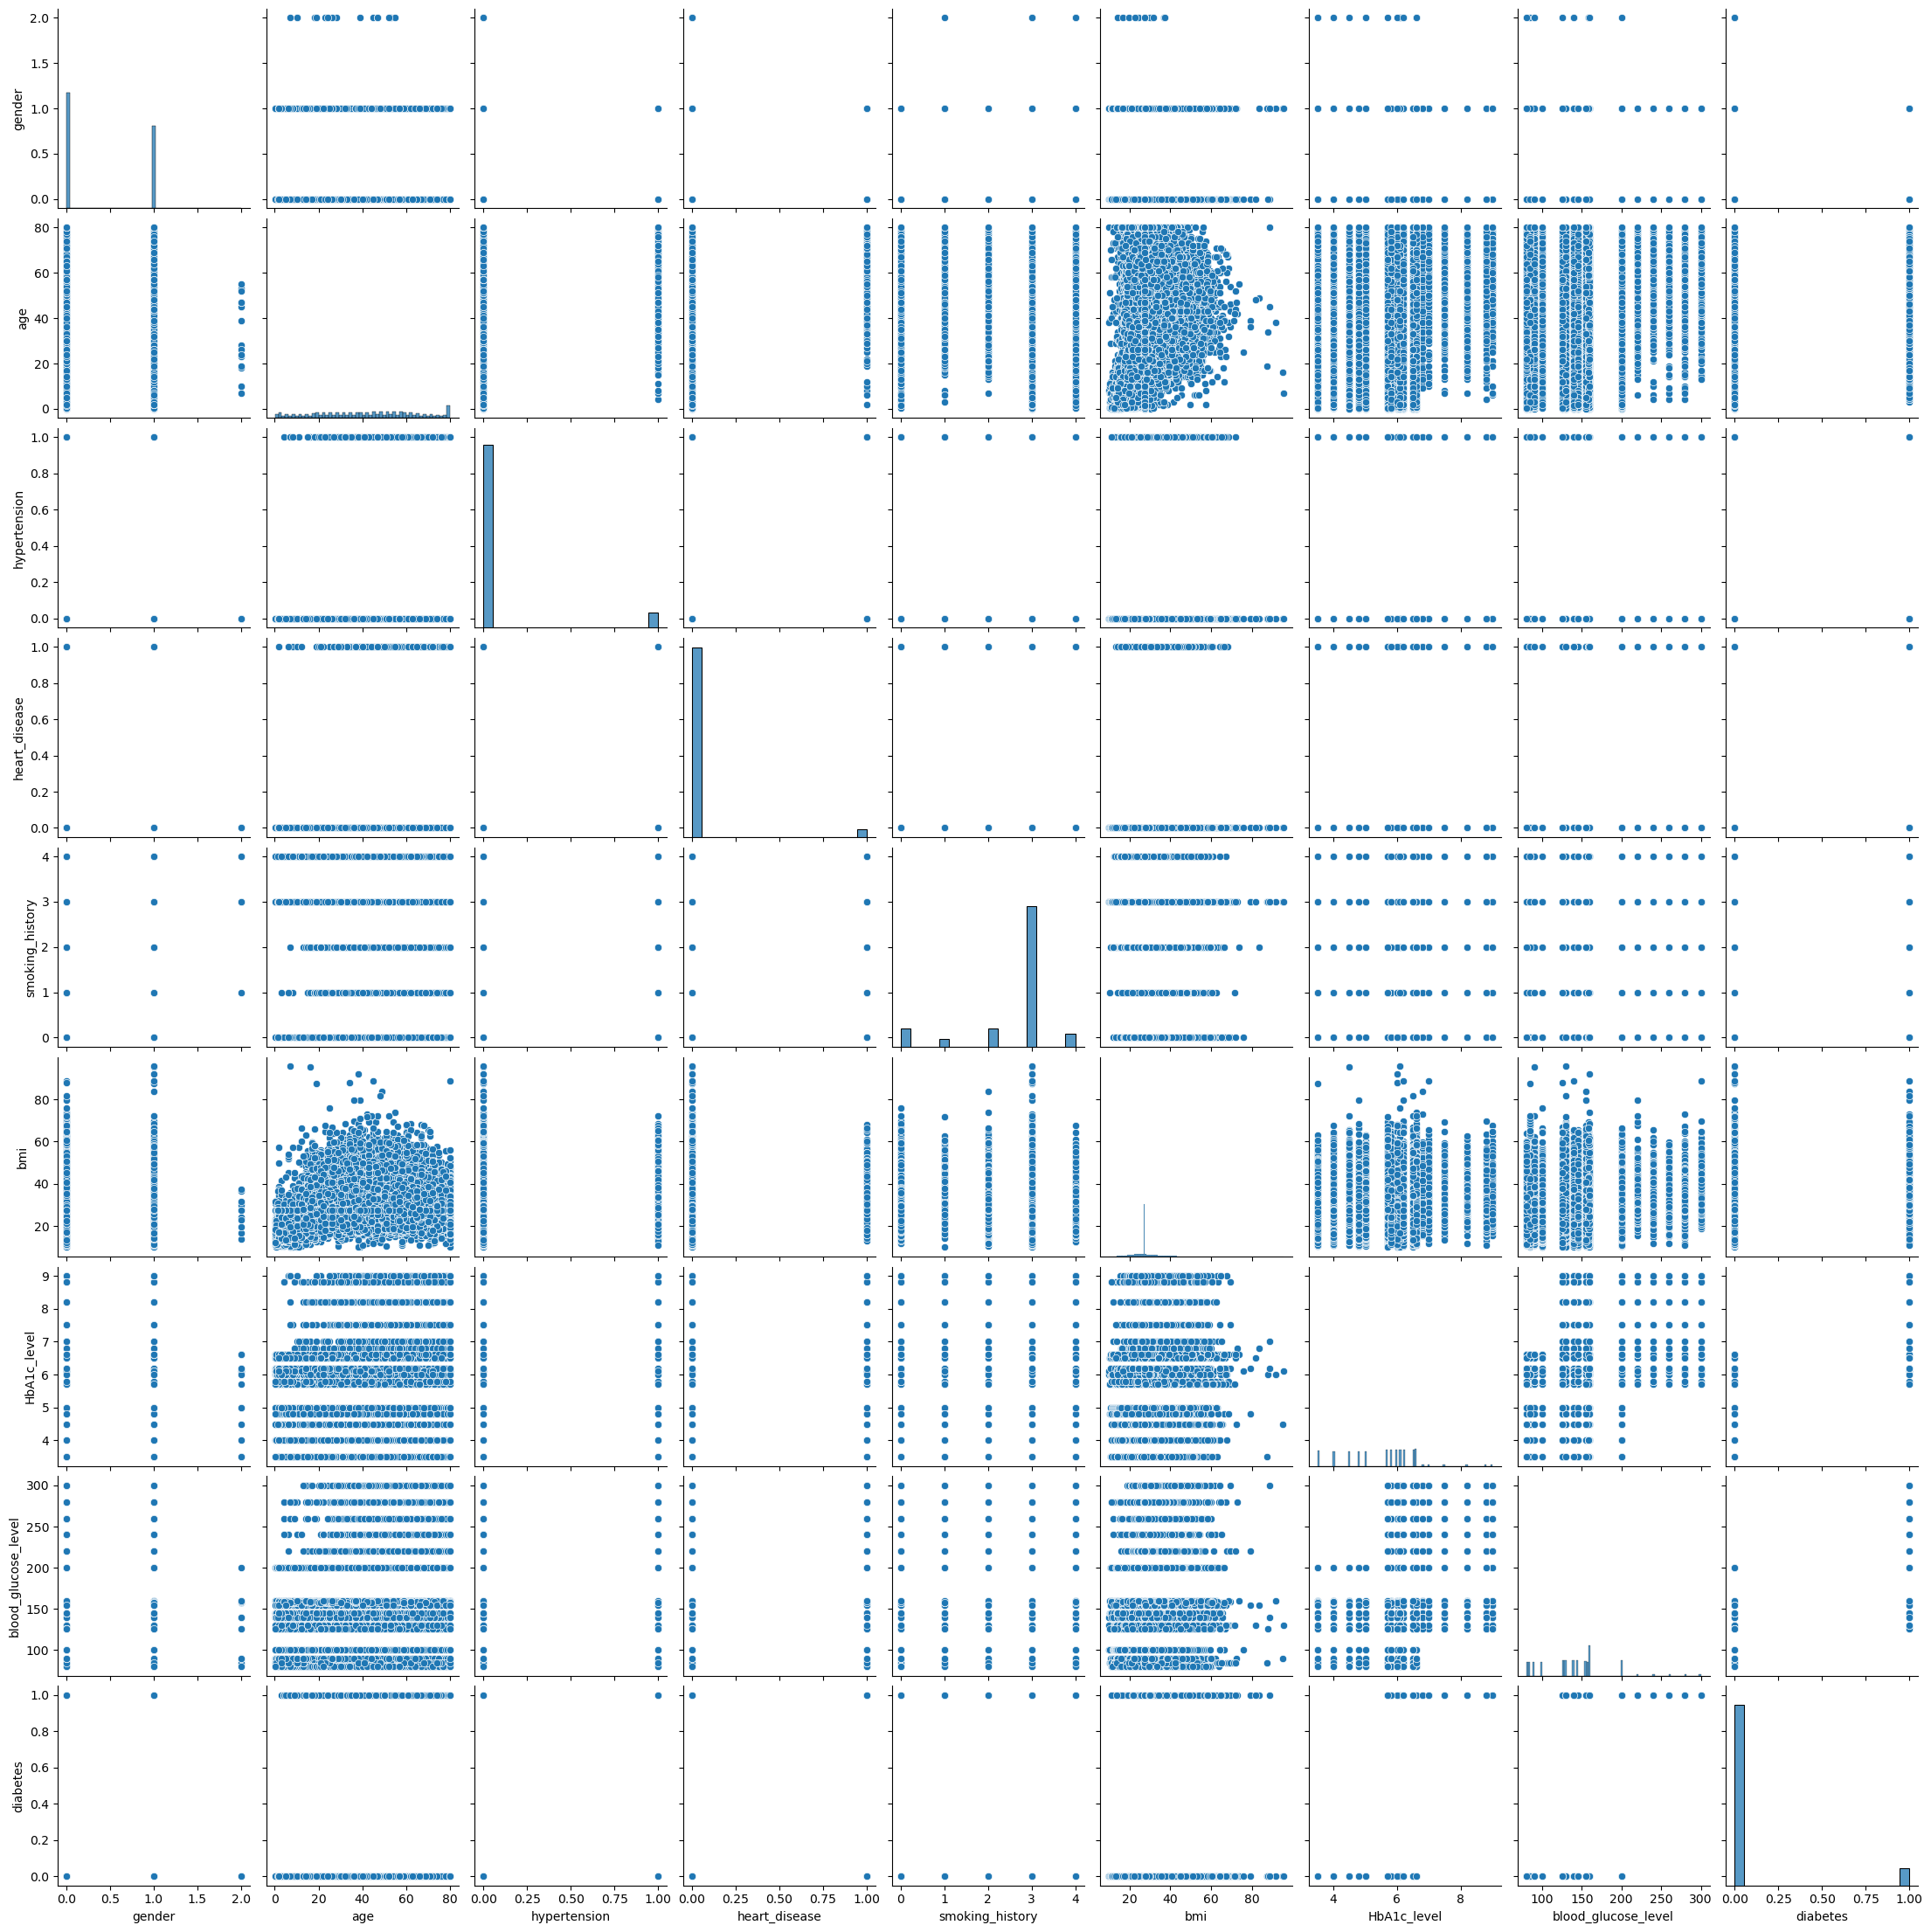

In [30]:
sns.pairplot(data)
plt.show()

In [31]:
data.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,1.000000,-0.030656,0.014203,0.077696,-0.044081,-0.022994,0.019957,0.017199,0.037411
age,-0.030656,1.000000,0.251171,0.233354,-0.098969,0.337396,0.101354,0.110672,0.258008
hypertension,0.014203,0.251171,1.000000,0.121262,-0.048631,0.147666,0.080939,0.084429,0.197823
heart_disease,0.077696,0.233354,0.121262,1.000000,-0.048253,0.061198,0.067589,0.070066,0.171727
smoking_history,-0.044081,-0.098969,-0.048631,-0.048253,1.000000,-0.087735,-0.017534,-0.022985,-0.049841
bmi,-0.022994,0.337396,0.147666,0.061198,-0.087735,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.019957,0.101354,0.080939,0.067589,-0.017534,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.017199,0.110672,0.084429,0.070066,-0.022985,0.091261,0.166733,1.000000,0.419558
diabetes,0.037411,0.258008,0.197823,0.171727,-0.049841,0.214357,0.400660,0.419558,1.000000


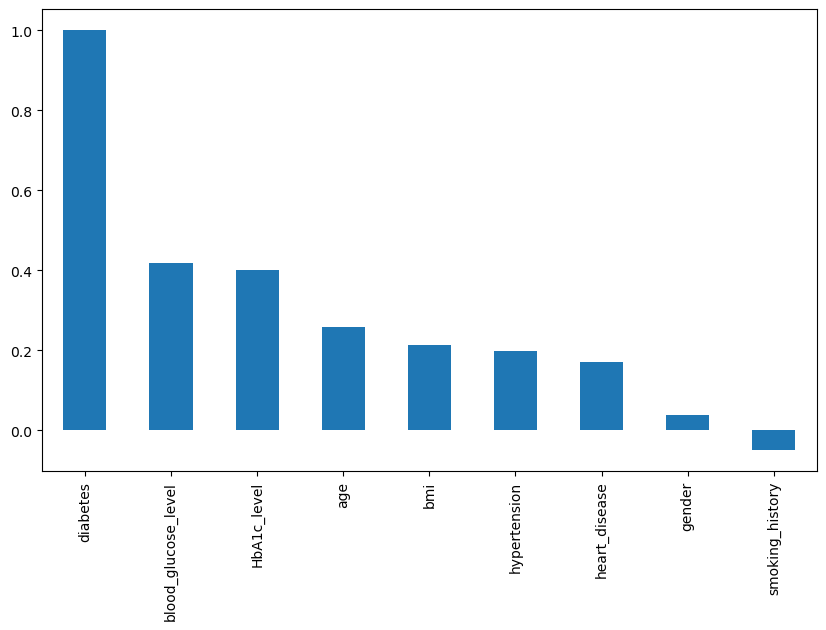

In [32]:
plt.figure(figsize=(10,6))
data.corr()['diabetes'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


In [34]:
x = data.loc[:,'age':'heart_disease'].join(data.loc[:,'bmi':'blood_glucose_level'])
x

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,80.0,0,1,25.19,6.6,140
1,54.0,0,0,27.32,6.6,80
2,28.0,0,0,27.32,5.7,158
3,36.0,0,0,23.45,5.0,155
4,76.0,1,1,20.14,4.8,155
...,...,...,...,...,...,...
99995,80.0,0,0,27.32,6.2,90
99996,2.0,0,0,17.37,6.5,100
99997,66.0,0,0,27.83,5.7,155
99998,24.0,0,0,35.42,4.0,100


In [35]:
y = data.loc[:,'diabetes']
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 100000, dtype: int64

### Data Splitting

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=0)

In [37]:
x_train.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
10382,2.0,0,0,16.45,6.2,159
73171,55.0,0,0,24.59,6.0,130
30938,24.0,0,0,21.77,4.5,130
99310,30.0,0,0,27.32,6.2,159
58959,13.0,0,0,18.37,6.5,130


In [38]:
print('Shape of Training  Data :')
print(x_train.shape)
print(y_train.shape)
print('Shape of Testing Data :')
print(x_test.shape)
print(y_test.shape)

Shape of Training  Data :
(80000, 6)
(80000,)
Shape of Testing Data :
(20000, 6)
(20000,)


In [40]:
ss = StandardScaler()
ss

StandardScaler()

In [41]:
x_train_scaled = ss.fit_transform(x_train)

In [43]:
if len(x_test.shape) == 1:
    x_test = x_test.values.reshape(-1,1)
x_test_scaled = ss.fit_transform(x_test)

In [44]:
model_lr = LogisticRegression()

In [45]:
model_lr.fit(x_train_scaled,y_train)

LogisticRegression()

In [46]:
y_pred = model_lr.predict(x_test_scaled)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [47]:
y_test[:10]

3582     0
60498    0
53227    0
21333    0
3885     0
51521    0
84261    0
10685    1
59948    0
41032    0
Name: diabetes, dtype: int64

In [48]:
accuracy_score(y_pred,y_test)

0.95975

In [49]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     18736
           1       0.63      0.86      0.73      1264

    accuracy                           0.96     20000
   macro avg       0.81      0.91      0.85     20000
weighted avg       0.97      0.96      0.96     20000



In [50]:
confusion_matrix(y_pred,y_test)

array([[18114,   622],
       [  183,  1081]])

In [51]:
y_train.value_counts()

diabetes
0    73203
1     6797
Name: count, dtype: int64

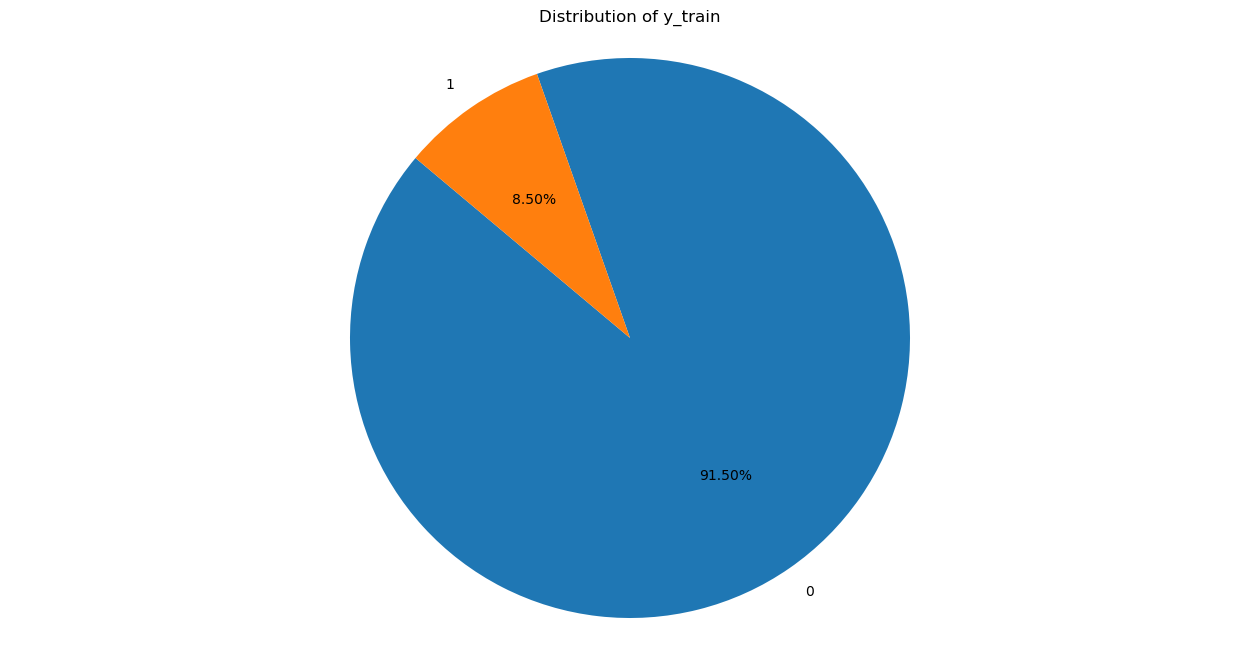

In [52]:
value_counts = y_train.value_counts()
plt.figure(figsize=(16,8))
plt.pie(value_counts , labels=value_counts.index , autopct = '%1.2f%%', startangle=140)
plt.title('Distribution of y_train')
plt.axis('Equal')
plt.show()

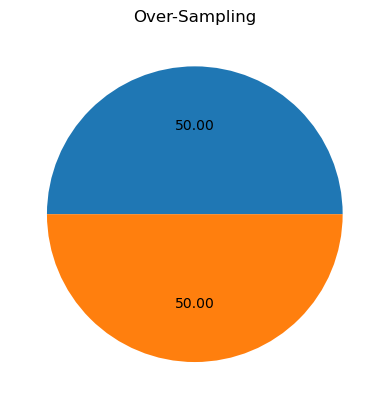

In [53]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_ovs,y_ovs = smote.fit_resample(x,y)
fig , oversp = plt.subplots()
oversp.pie(y_ovs.value_counts(),autopct='%.2f')
oversp.set_title('Over-Sampling')
plt.show()

In [54]:
xr_train,xr_test,yr_train,yr_test = train_test_split(x_ovs,y_ovs,train_size=0.7,random_state=42)

In [55]:
print('Train Data Shape :')
print(xr_train.shape)
print(yr_train.shape)
print('Test Data Shape :')
print(xr_test.shape)
print(yr_test.shape)

Train Data Shape :
(128099, 6)
(128099,)
Test Data Shape :
(54901, 6)
(54901,)


In [56]:
print('y_train and y_test value_counts :')
print(yr_train.value_counts())
print(yr_test.value_counts())

y_train and y_test value_counts :
diabetes
0    64131
1    63968
Name: count, dtype: int64
diabetes
1    27532
0    27369
Name: count, dtype: int64


In [57]:
ss = StandardScaler()
ss

StandardScaler()

In [58]:
data = xr_train,xr_test
xr_train_sc = ss.fit_transform(xr_train)
xr_test_sc = ss.fit_transform(xr_test)

In [60]:
xr_train_scaled = pd.DataFrame(xr_train_sc)
print(xr_train_scaled.shape)
xr_train_scaled.head()
print(yr_train.shape)

(128099, 6)
(128099,)


In [61]:
xr_test_scaled = pd.DataFrame(xr_test_sc)
print(xr_test_scaled.shape)
xr_test_scaled.head()

(54901, 6)


,0,1,2,3,4,5
0,0.257157,-0.293639,-0.203152,-0.112490,0.992563,-0.656415
1,-1.099493,-0.293639,-0.203152,-0.402643,0.371966,-0.062069
2,-1.471187,-0.293639,-0.203152,-0.285666,0.371966,-1.460530
3,-0.774260,3.405547,-0.203152,0.291059,0.371966,-1.373126
4,-1.378263,-0.293639,-0.203152,-0.285666,-2.157709,-1.110915


In [62]:
model_lk = LogisticRegression()
model_lk.fit(xr_train_scaled,yr_train)

LogisticRegression()

In [63]:
y_pred_lr = model_lk.predict(xr_test_scaled)
y_pred_lr[:10]

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 1])

In [64]:
yr_test[:10]

180328    1
573       0
13494     0
93981     0
75389     0
180973    1
71021     0
19293     0
16393     0
121419    1
Name: diabetes, dtype: int64

In [66]:
print(classification_report(y_pred_lr,yr_test))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88     27299
           1       0.89      0.88      0.89     27602

    accuracy                           0.89     54901
   macro avg       0.89      0.89      0.89     54901
weighted avg       0.89      0.89      0.89     54901



In [67]:
confusion_matrix(y_pred_lr,yr_test)

array([[24186,  3113],
       [ 3183, 24419]])

In [68]:
model_dtc = DecisionTreeClassifier()
model_dtc.fit(xr_train_scaled,yr_train)
model_dtc

DecisionTreeClassifier()

In [69]:
y_pred_dtc = model_dtc.predict(xr_test_scaled)

In [70]:
print(classification_report(y_pred_dtc,yr_test))

              precision    recall  f1-score   support

           0       0.76      0.99      0.86     20933
           1       0.99      0.81      0.89     33968

    accuracy                           0.88     54901
   macro avg       0.88      0.90      0.87     54901
weighted avg       0.90      0.88      0.88     54901



In [71]:
confusion_matrix(y_pred_dtc,yr_test)

array([[20750,   183],
       [ 6619, 27349]])

In [73]:
model_rfc = RandomForestClassifier()
model_rfc.fit(xr_train_scaled,yr_train)

RandomForestClassifier()

In [74]:
y_pred_rfc = model_rfc.predict(xr_test_scaled)

In [75]:
print(classification_report(y_pred_rfc,yr_test))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     24785
           1       0.99      0.90      0.94     30116

    accuracy                           0.94     54901
   macro avg       0.94      0.94      0.94     54901
weighted avg       0.94      0.94      0.94     54901



In [76]:
confusion_matrix(y_pred_rfc,yr_test)

array([[24436,   349],
       [ 2933, 27183]])

In [77]:
model_xgb = XGBClassifier()
model_xgb.fit(xr_train_scaled,yr_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
y_pred_xgb = model_xgb.predict(xr_test_scaled)

In [79]:
print(classification_report(y_pred_xgb,yr_test))

              precision    recall  f1-score   support

           0       0.68      0.97      0.80     19201
           1       0.98      0.75      0.85     35700

    accuracy                           0.83     54901
   macro avg       0.83      0.86      0.82     54901
weighted avg       0.87      0.83      0.83     54901



In [80]:
confusion_matrix(y_pred_xgb,yr_test)

array([[18589,   612],
       [ 8780, 26920]])

### Hyper-Parameter Tunning And Best Param Grid

In [83]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  
    'penalty': ['l1', 'l2']                
}

logistic = LogisticRegression()

grid_search = GridSearchCV(estimator=logistic, param_grid=param_grid, cv=10)

accuracy_scores = []

for _ in range(10):
    grid_search.fit(xr_train_scaled, yr_train)
    best_params = grid_search.best_params_
    cv_scores = cross_val_score(grid_search.best_estimator_, xr_train_scaled, yr_train, cv=10)
    accuracy_scores.append(cv_scores.mean())

print("Accuracy scores over 10 iterations:", ["{:.2f}".format(score) for score in accuracy_scores])

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters found:", best_params)
print("Best cross-validation score:", best_score)

Accuracy scores over 10 iterations: ['0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89', '0.89']
Best parameters found: {'C': 0.001, 'penalty': 'l2'}
Best cross-validation score: 0.8857211803834504


### Final Model

In [84]:
from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(C=0.001,penalty='l2')
final_model.fit(xr_train_scaled,yr_train)

LogisticRegression(C=0.001)

In [85]:
import pickle
with open('final_model.pkl','wb') as file:
    pickle.dump(final_model,file)

In [86]:
import pickle
import numpy as np

with open('final_model.pkl','rb') as file :
    loaded_model = pickle.load(file)
mean_values = [41.885856, 0.07485, 0.03942, 27.320767, 5.527507, 138.058060]
std_values = [22.516840, 0.26315, 0.194593, 6.636783, 1.070672, 40.708136]

age = 30
hypertension = 0
heart_disease = 0
bmi = 100.0
HbA1c_level = 5.0
blood_glucose_level = 90

scaled_features = [(x - mean) / std for x, mean, std in zip(
    [age, hypertension, heart_disease, bmi, HbA1c_level, blood_glucose_level],
    mean_values, std_values
)]

prediction = loaded_model.predict([scaled_features])

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Not Diabetic")

Diabetic
